In [1]:
import csv
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import glob

Calculate the overlap numbers between traning datasets

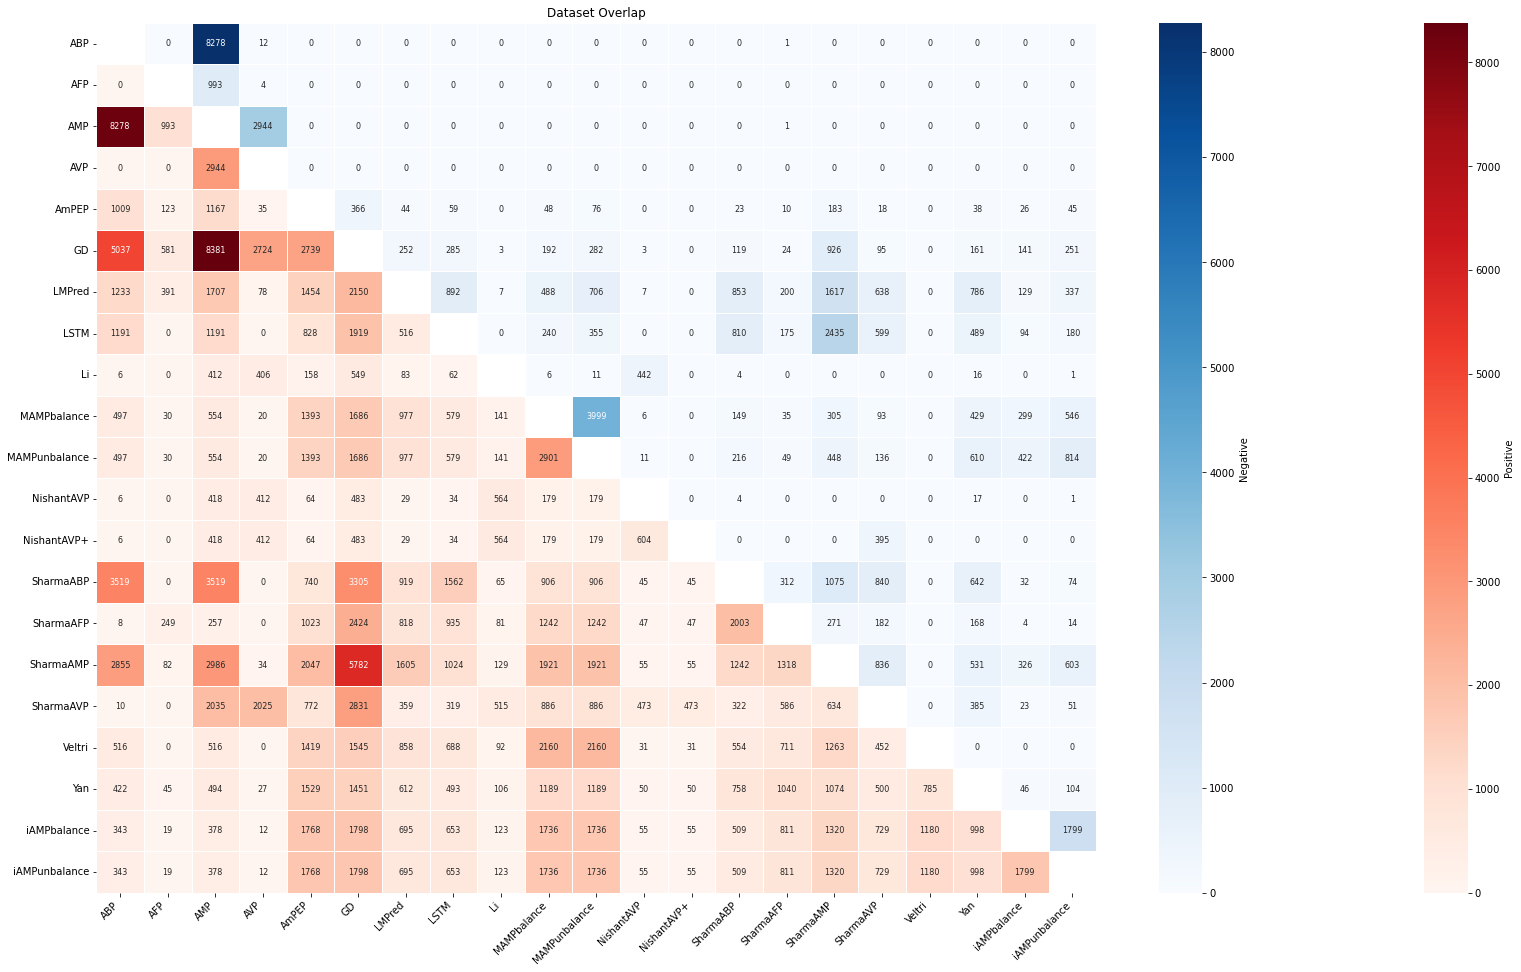

<Figure size 432x288 with 0 Axes>

In [ ]:
def merge_datasets(train_folder):
    merged_data = defaultdict(list)
    train_folder += '/*'
    for file_name in glob.glob(train_folder):
        if file_name.endswith('_tr.csv'):
            train_file = file_name
        if file_name.endswith('_te.csv'):
            test_file = file_name

    # Merge train data
    with open(train_file, 'r') as train_csv:
        train_reader = csv.reader(train_csv)
        for row in train_reader:
            merged_data[row[0]].append(int(row[1]))

    # Merge test data
    with open(test_file, 'r') as test_csv:
        test_reader = csv.reader(test_csv)
        for row in test_reader:
            merged_data[row[0]].append(int(row[1]))

    return merged_data

def calculate_overlap(dataset1, dataset2):
    positive_overlap = 0
    negative_overlap = 0

    for sequence, labels in dataset1.items():
        if sequence in dataset2:
            labels2 = dataset2[sequence]
            for label in labels:
                if label == 1 and 1 in labels2:
                    positive_overlap += 1
                elif label == 0 and 0 in labels2:
                    negative_overlap += 1

    return positive_overlap, negative_overlap

def datasets_name_extraction(datasets):
    rec = []
    for dataset in datasets:
        dataset = dataset.split('/')[-1]
        if '_' in dataset and 'pre' in dataset:
            dataset = dataset.split('_')[0] + dataset.split('_')[2]
        elif "_" in dataset and "Yan" in dataset:
            dataset = dataset.split('_')[0]
        elif "_" in dataset and "Li" in dataset:
            dataset = dataset.split('_')[0]
        elif "_" in dataset and "Veltri" in dataset:
            dataset = dataset.split('_')[0]    
        elif "_" in dataset:
            dataset = dataset.split('_')[0] + dataset.split('_')[1]
        elif "General" in dataset:
            dataset = 'GD'
        else:
            dataset = dataset
        rec.append(dataset)
    return rec
folder_path = './Database/*'  # Replace with the path to your folder containing the CSV files
datasets = glob.glob(folder_path)
datasets = sorted(datasets)

dataset_names = datasets_name_extraction(datasets)
# Initialize matrices to store overlap counts
num_datasets = len(datasets)
positive_overlap_matrix = np.zeros((num_datasets, num_datasets))
negative_overlap_matrix = np.zeros((num_datasets, num_datasets))
overlap_matrix = np.zeros((num_datasets, num_datasets))

# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)

        overlap_matrix[i, j] = negative_overlap 
        overlap_matrix[j, i] = positive_overlap


mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(28, 16))
sns.heatmap(overlap_matrix, mask=mask, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Positive'}, annot_kws={"fontsize":8})
sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":8})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()
plt.savefig('Dataset Overlap.pdf', dpi=1000)


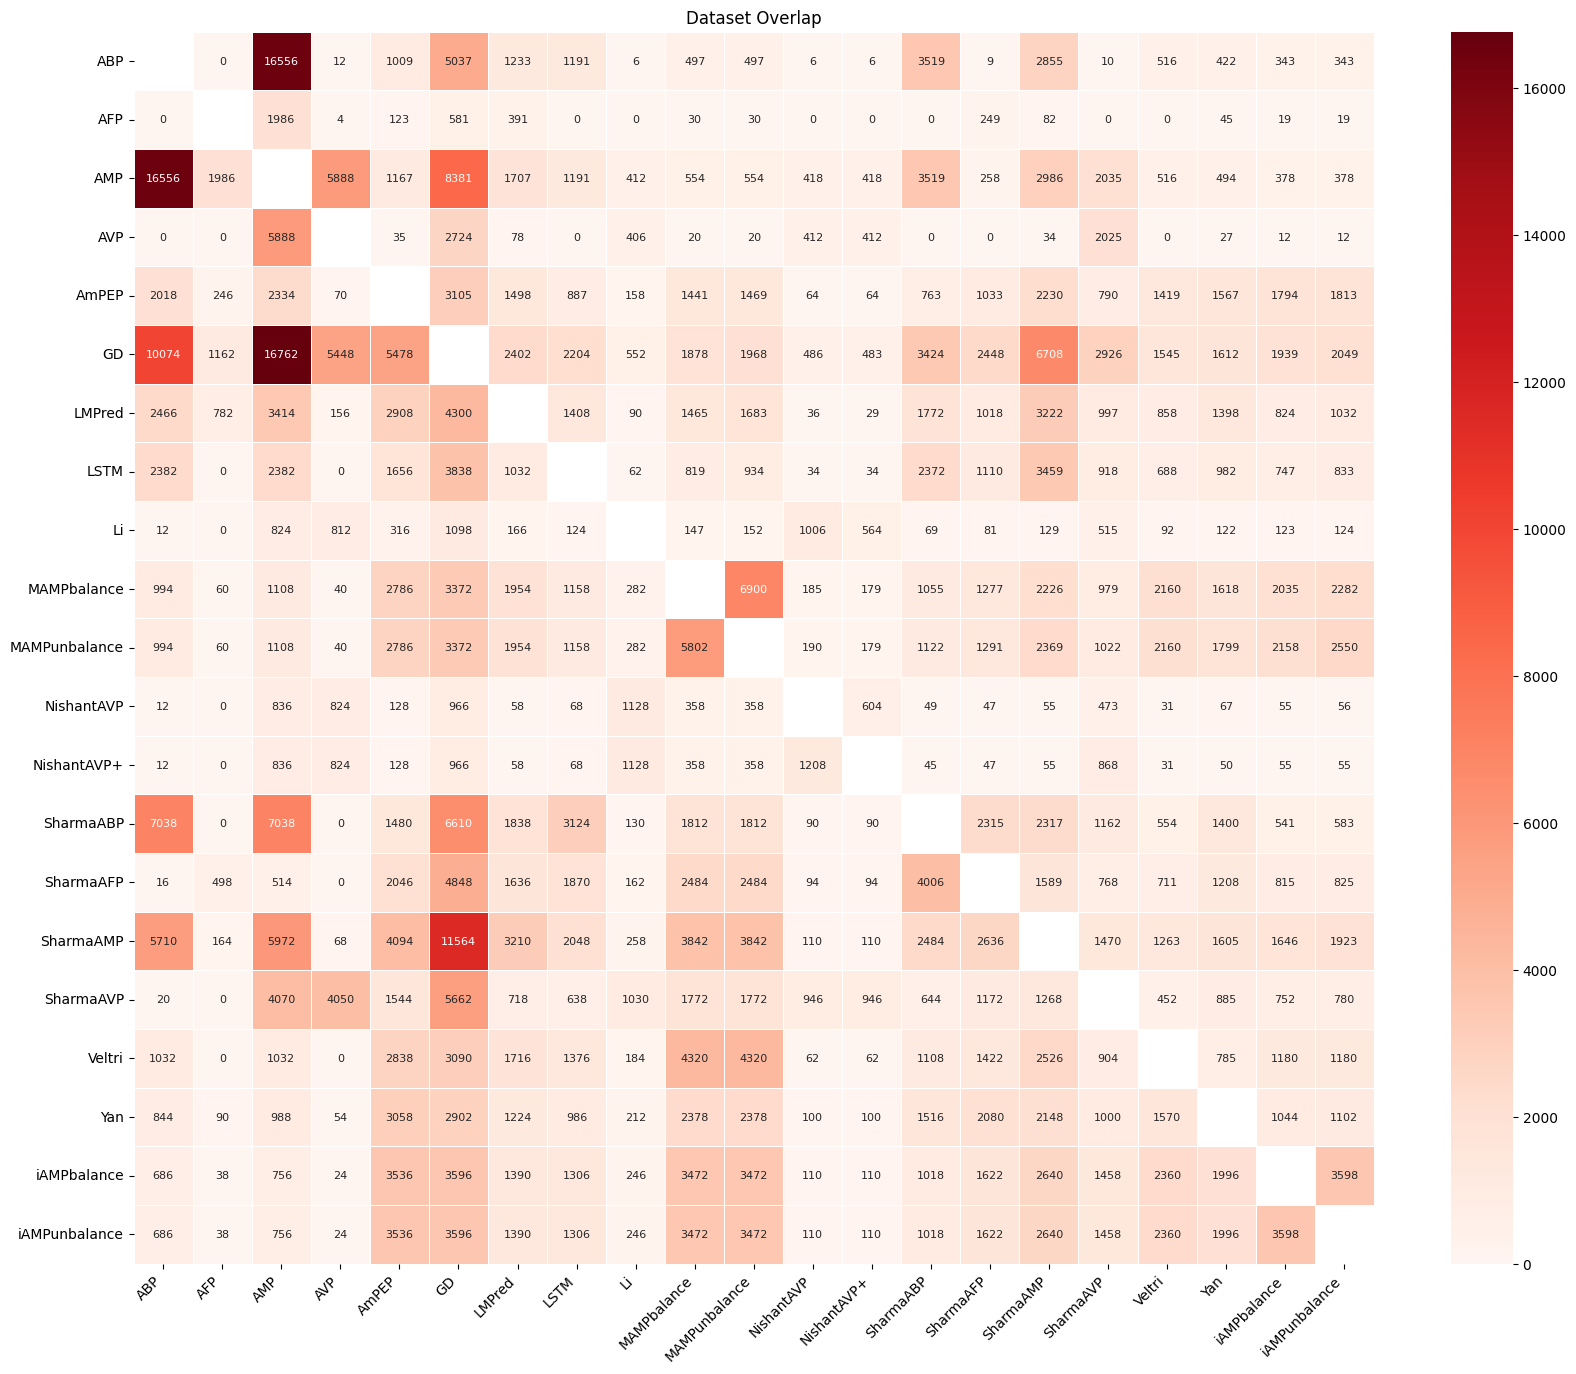

In [6]:
# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)

        overlap_matrix[i, j] = negative_overlap + positive_overlap
        overlap_matrix[j, i] = positive_overlap + positive_overlap


mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(20, 16))
sns.heatmap(overlap_matrix, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5, annot_kws={"fontsize":8})
#sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":6})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()

In [ ]:
# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)

        overlap_matrix[i, j] = negative_overlap + positive_overlap
        overlap_matrix[j, i] = positive_overlap + positive_overlap


mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(20, 16))
sns.heatmap(overlap_matrix, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5, annot_kws={"fontsize":8})
#sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":6})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()

Calculate the Jaccard similarity between training datasets

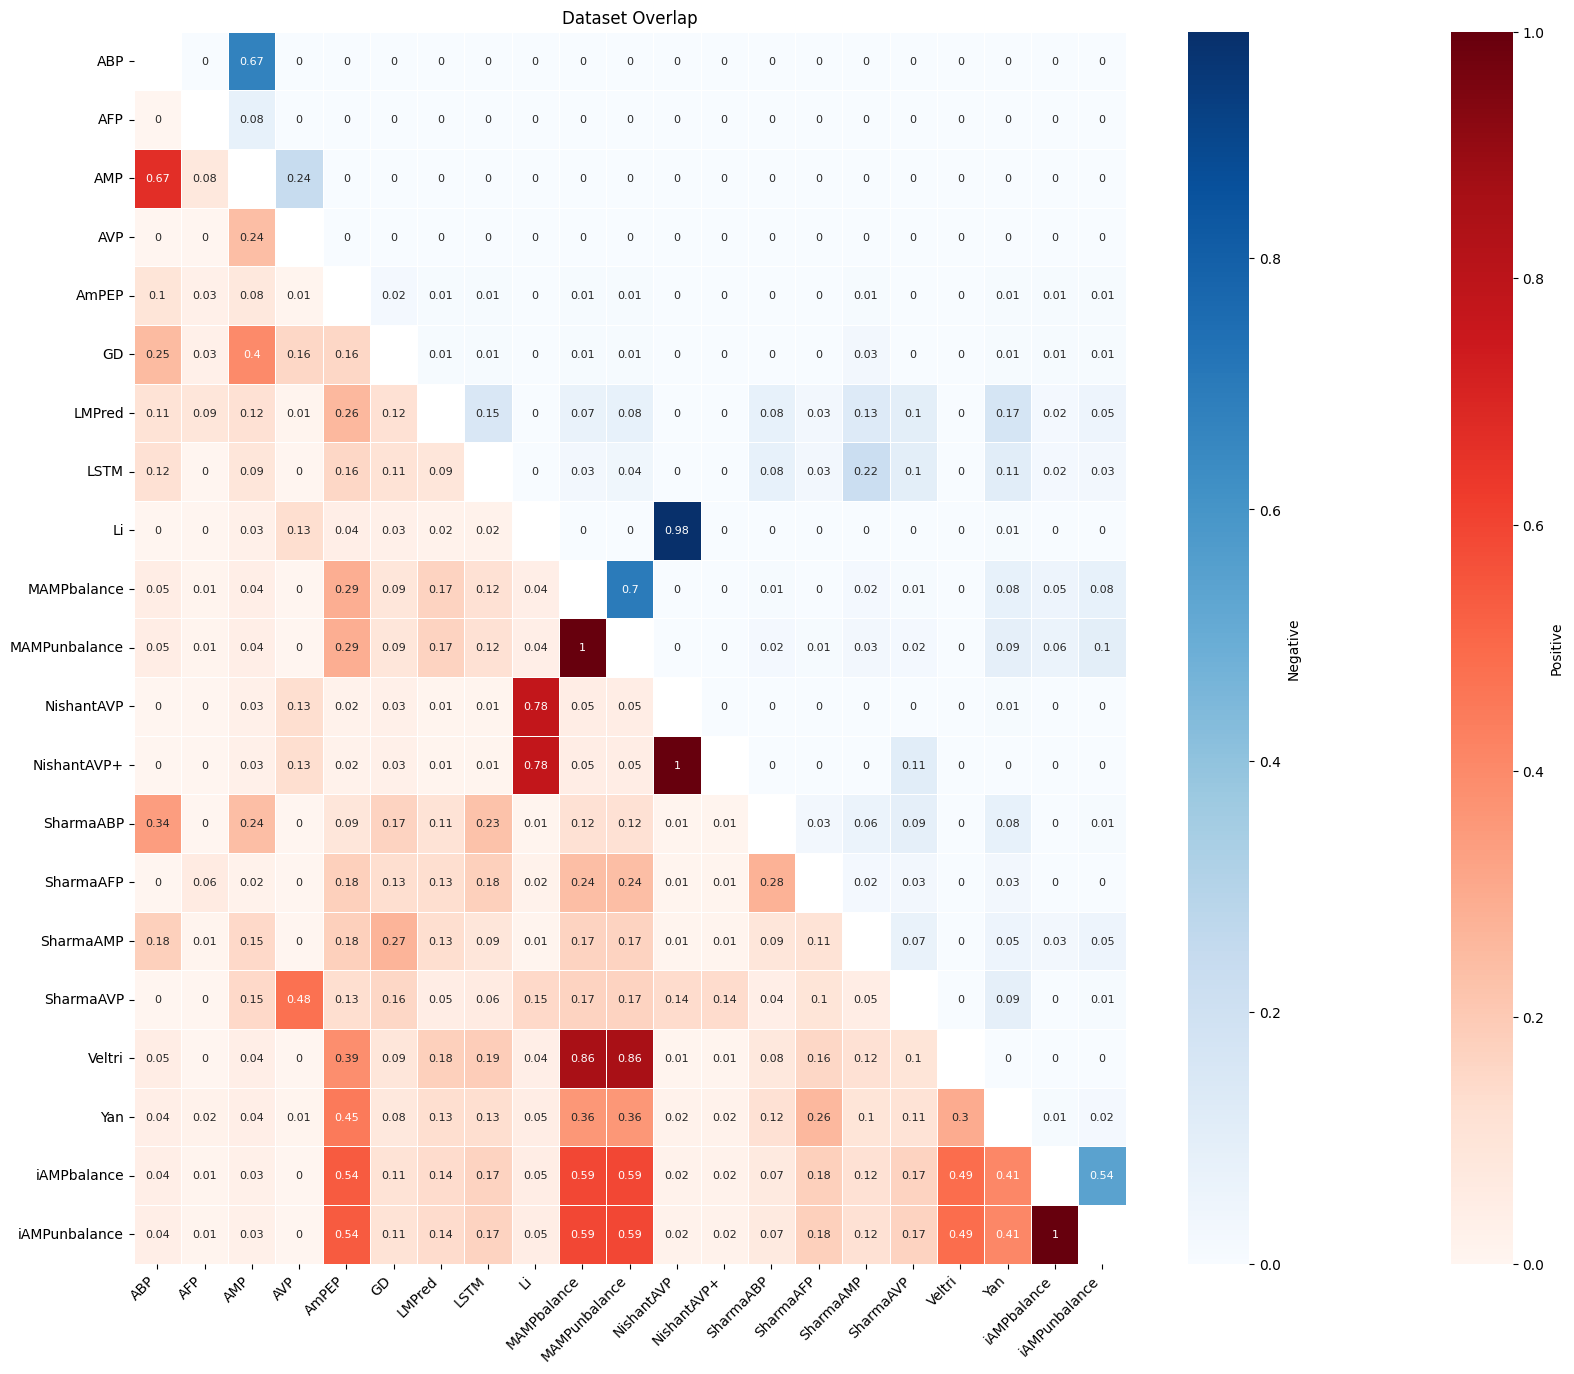

In [ ]:
def merge_datasets(train_folder):
    merged_data = defaultdict(list)
    train_folder += '/*'
    for file_name in glob.glob(train_folder):
        if file_name.endswith('_tr.csv'):
            train_file = file_name
        if file_name.endswith('_te.csv'):
            test_file = file_name

    # Merge train data
    with open(train_file, 'r') as train_csv:
        train_reader = csv.reader(train_csv)
        for row in train_reader:
            merged_data[row[0]].append(int(row[1]))

    # Merge test data
    with open(test_file, 'r') as test_csv:
        test_reader = csv.reader(test_csv)
        for row in test_reader:
            merged_data[row[0]].append(int(row[1]))

    return merged_data

def calculate_overlap(dataset1, dataset2):
    positive_overlap = 0
    negative_overlap = 0

    for sequence, labels in dataset1.items():
        if sequence in dataset2:
            labels2 = dataset2[sequence]
            for label in labels:
                if label == 1 and 1 in labels2:
                    positive_overlap += 1
                elif label == 0 and 0 in labels2:
                    negative_overlap += 1

    return positive_overlap, negative_overlap
def count_sample(datasets):
    p = 0
    n = 0
    for sequence, labels in datasets.items():
        for label in labels:
            if label==0:
                n += 1
            if label==1:
                p += 1
    return p,n
def datasets_name_extraction(datasets):
    rec = []
    for dataset in datasets:
        dataset = dataset.split('/')[-1]
        if '_' in dataset and 'pre' in dataset:
            dataset = dataset.split('_')[0] + dataset.split('_')[2]
        elif "_" in dataset and "Yan" in dataset:
            dataset = dataset.split('_')[0]
        elif "_" in dataset and "Li" in dataset:
            dataset = dataset.split('_')[0]
        elif "_" in dataset and "Veltri" in dataset:
            dataset = dataset.split('_')[0]    
        elif "_" in dataset:
            dataset = dataset.split('_')[0] + dataset.split('_')[1]
        elif "General" in dataset:
            dataset = 'GD'
        else:
            dataset = dataset
        rec.append(dataset)
    return rec
folder_path = './Database/*'  # Replace with the path to your folder containing the CSV files
datasets = glob.glob(folder_path)
datasets = sorted(datasets)
dataset_names = datasets_name_extraction(datasets)
# Initialize matrices to store overlap counts
num_datasets = len(datasets)
positive_overlap_matrix = np.zeros((num_datasets, num_datasets))
negative_overlap_matrix = np.zeros((num_datasets, num_datasets))
overlap_matrix = np.zeros((num_datasets, num_datasets))
# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        dataset1_p,dataset1_n =count_sample(dataset1)
        dataset2_p,dataset2_n =count_sample(dataset2)
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)
        overlap_matrix[i, j] = round(negative_overlap/(dataset1_n+dataset2_n-negative_overlap),2) 
        overlap_matrix[j, i] = round(positive_overlap/(dataset1_p+dataset2_p-positive_overlap),2)


mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(20, 16))
sns.heatmap(overlap_matrix, mask=mask, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Positive'}, annot_kws={"fontsize":8})
sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":8})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()


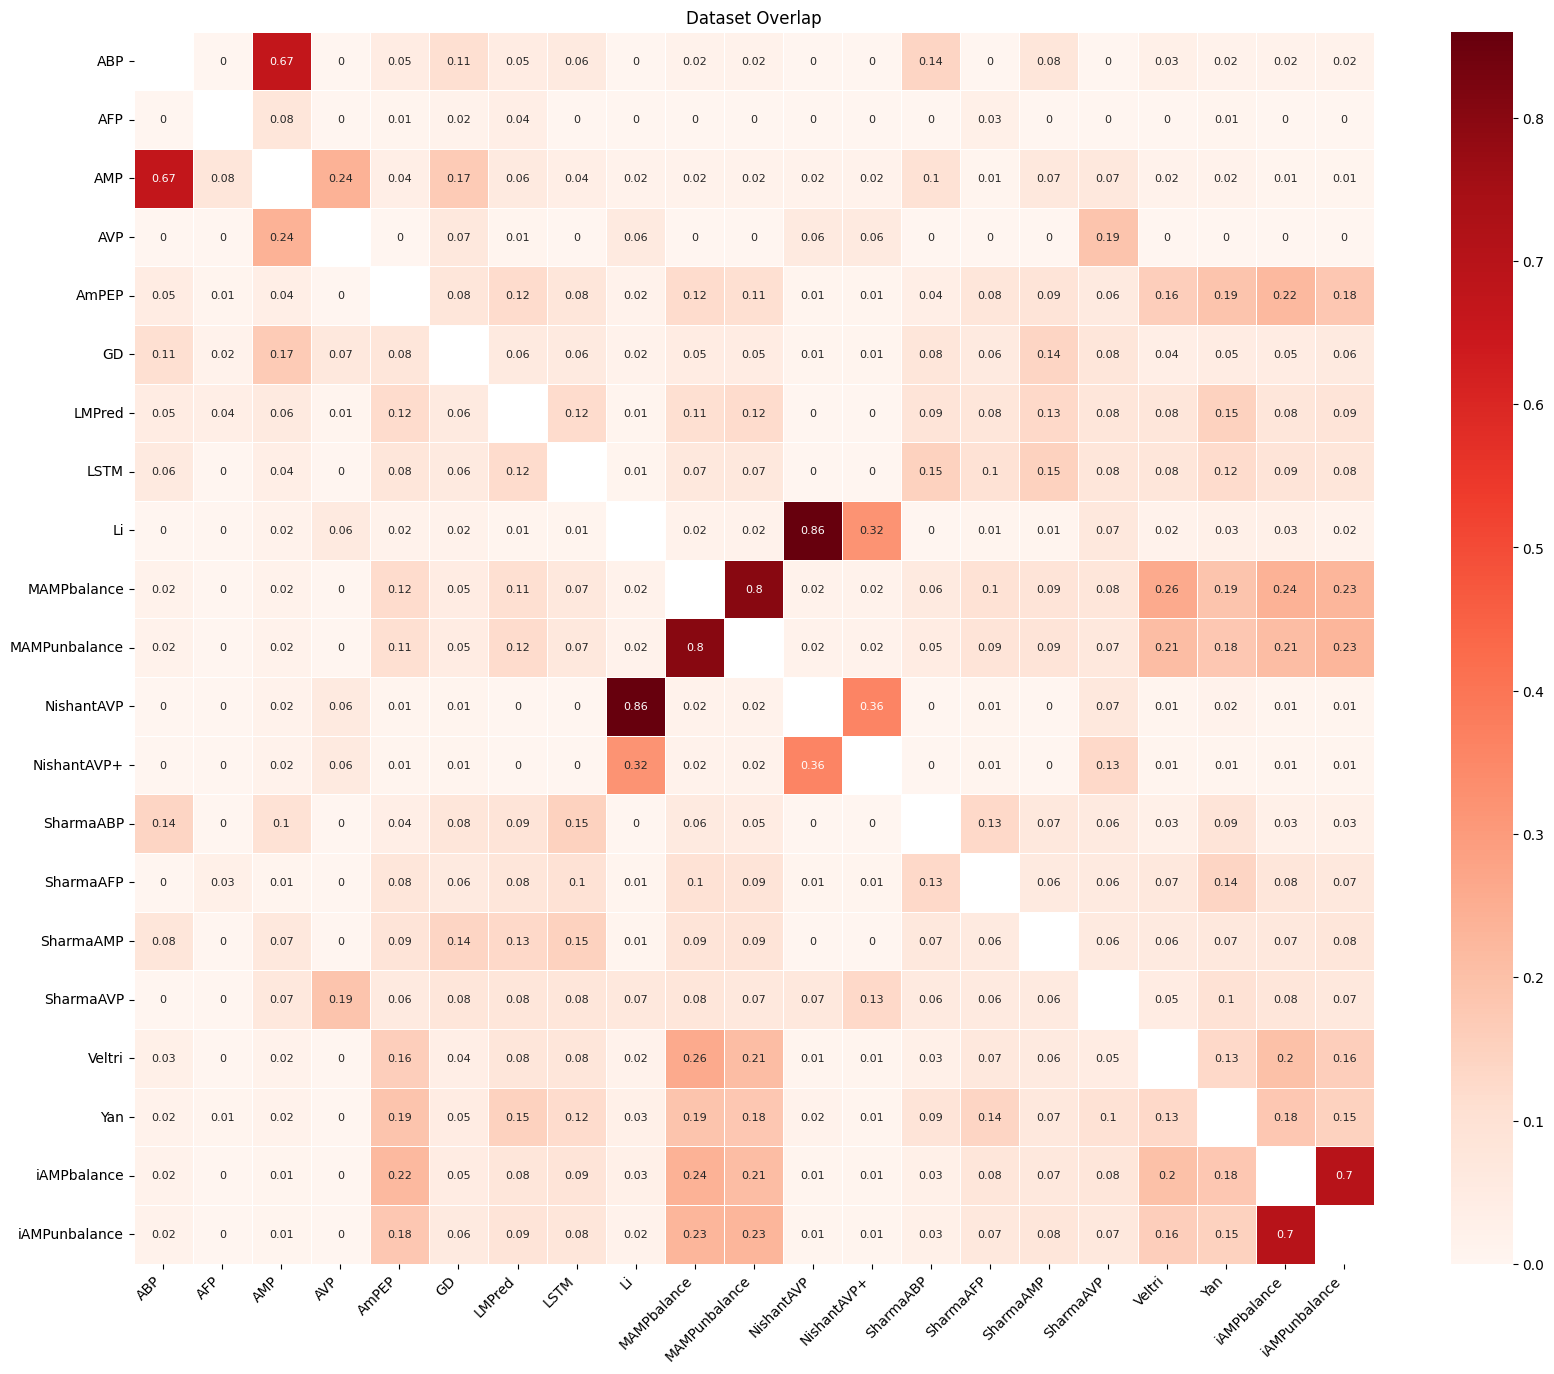

In [8]:
# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)

        dataset1_p,dataset1_n =count_sample(dataset1)
        dataset2_p,dataset2_n =count_sample(dataset2)
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)
        overlap_matrix[i, j] = round((positive_overlap+negative_overlap)/(dataset1_n+dataset2_n-negative_overlap+dataset1_p+dataset2_p-positive_overlap),2)
        overlap_matrix[j, i] = round((positive_overlap+negative_overlap)/(dataset1_n+dataset2_n-negative_overlap+dataset1_p+dataset2_p-positive_overlap),2)

mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(20, 16))
sns.heatmap(overlap_matrix, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5, annot_kws={"fontsize":8})
#sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":6})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()

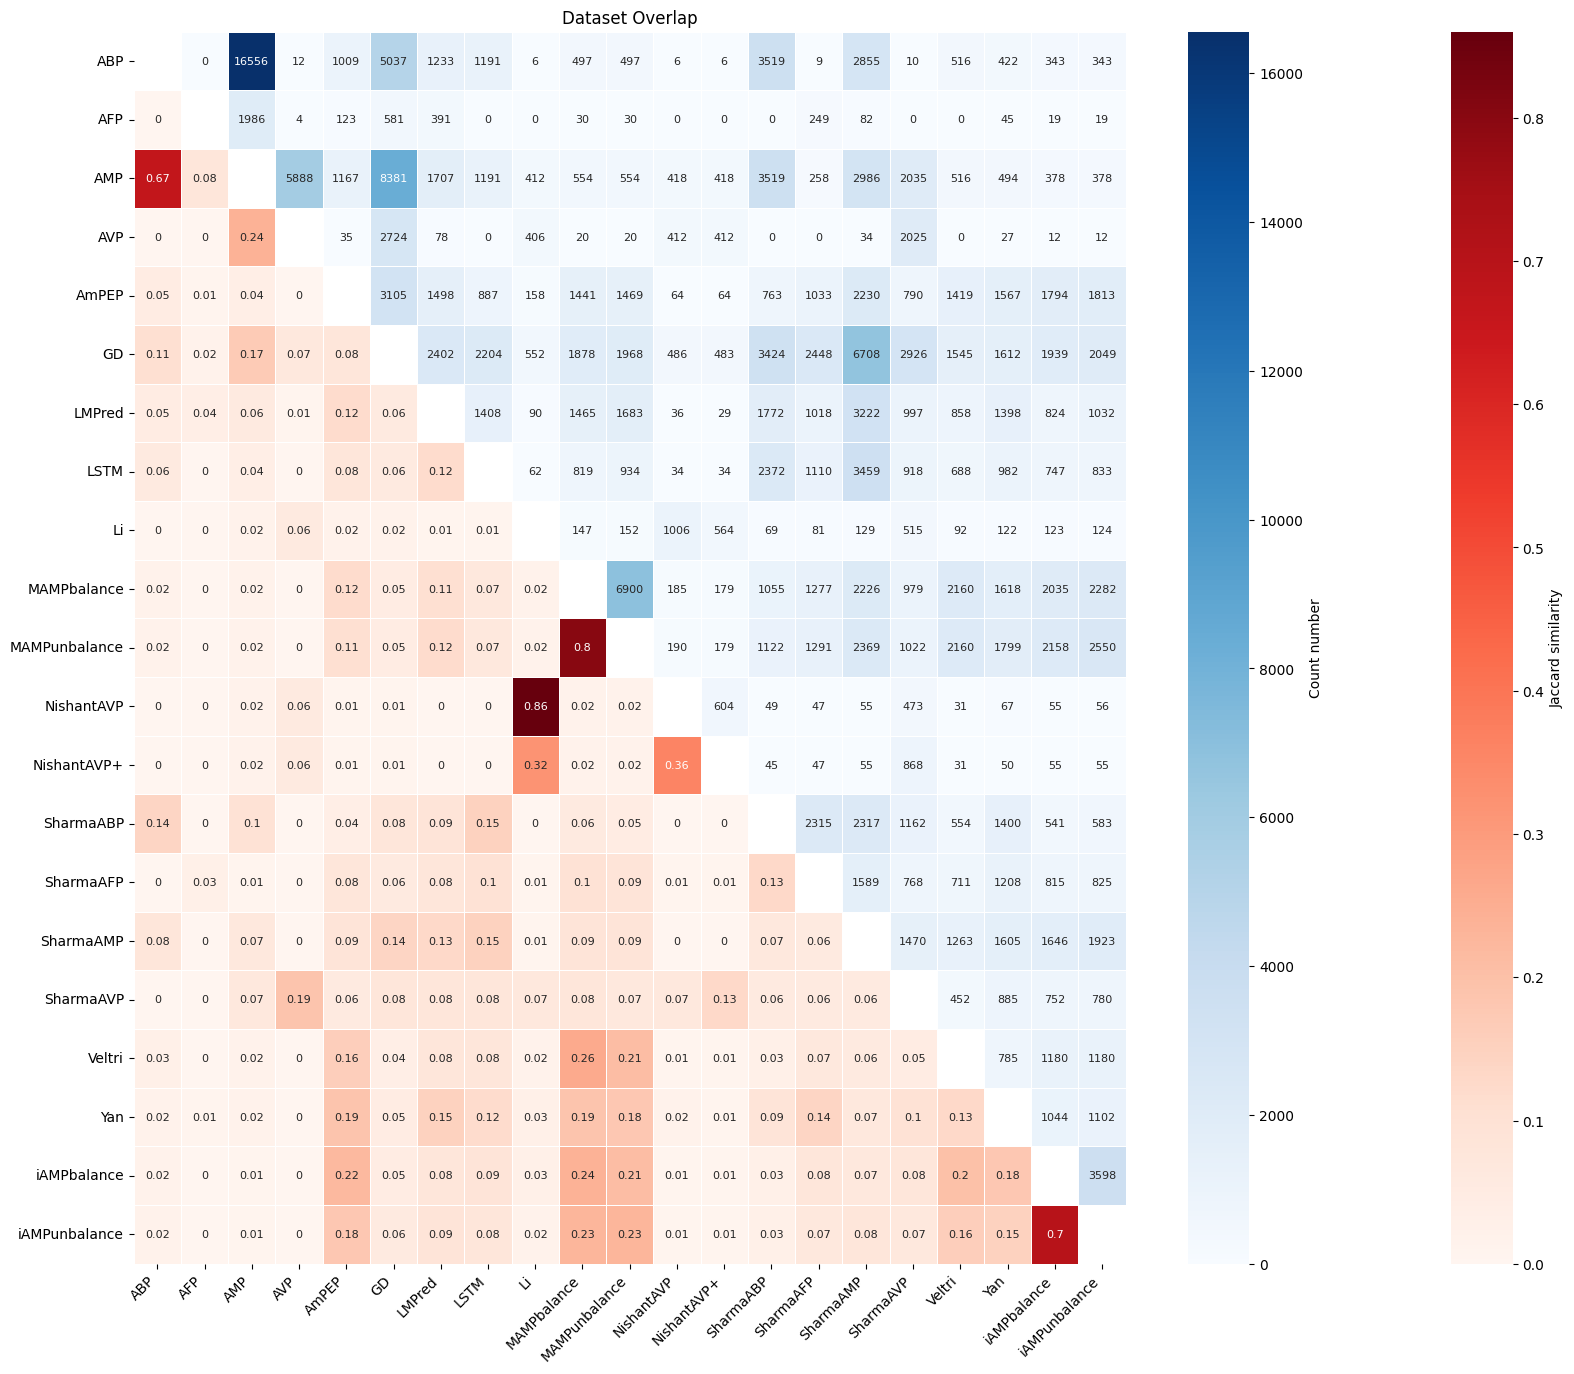

In [9]:
# Calculate overlaps
for i in range(num_datasets):
    for j in range(i+1, num_datasets):
        dataset1 = merge_datasets(datasets[i])
        dataset2 = merge_datasets(datasets[j])
        positive_overlap, negative_overlap = calculate_overlap(dataset1, dataset2)

        overlap_matrix[i, j] = negative_overlap + positive_overlap
        dataset1_p,dataset1_n =count_sample(dataset1)
        dataset2_p,dataset2_n =count_sample(dataset2)
        overlap_matrix[j, i] = round((positive_overlap+negative_overlap)/(dataset1_n+dataset2_n-negative_overlap+dataset1_p+dataset2_p-positive_overlap),2)

mask = np.triu(np.ones_like(overlap_matrix, dtype=bool))
np.fill_diagonal(overlap_matrix, np.nan)
plt.figure(figsize=(20, 16))
sns.heatmap(overlap_matrix, mask=mask, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Jaccard similarity'}, annot_kws={"fontsize":8})
sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Count number'},annot_kws={"fontsize":8})
#sns.heatmap(overlap_matrix, cmap='Reds', annot=True, fmt="g", cbar=True, linewidths=.5, annot_kws={"fontsize":6})
#sns.heatmap(overlap_matrix, mask=~mask, cmap='Blues', annot=True, fmt="g", cbar=True, linewidths=.5,cbar_kws={'label': 'Negative'},annot_kws={"fontsize":6})
plt.xticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=45, ha='right')
plt.yticks(ticks=np.arange(num_datasets) + 0.5, labels=dataset_names, rotation=0)
plt.title('Dataset Overlap')
plt.show()

Statistics for numbers of datasets and the overlap numbers between positive samples and negtive samples

In [ ]:
import os
import pandas as pd
import glob
def overlap_count(dataset):
    pos_set = set()
    neg_set = set()
    dataset += '/*'
    files = glob.glob(dataset)
    for file_name in files:
        if file_name.endswith('.csv'):
            if '_tr.csv' in file_name:
                with open (file_name,'r') as f:
                    for line in f:
                        line =line.split(',')
                        if int(line[1])==1:
                            pos_set.add(str(line[0].strip()))
                        else:
                            neg_set.add(str(line[0].strip()))
            if '_te.csv' in file_name:
                with open (file_name,'r') as f:
                    for line in f:
                        line =line.split(',')
                        if int(line[1])==1:
                            pos_set.add(str(line[0].strip()))
                        else:
                            neg_set.add(str(line[0].strip()))
    return len(pos_set.intersection(neg_set))
def count_training_datasets(folder_path):
    pos_seq_tr = []
    neg_seq_tr = []
    pos_seq_te = []
    neg_seq_te = []
    total_training_datasets = 0
    pos_tr =0
    neg_tr =0
    pos_te = 0
    neg_te = 0
    folder_path += '/*'
    files = glob.glob(folder_path)
    
    for file_name in files:
        if file_name.endswith('.csv'):
            # Assuming training datasets end with '_train.csv' in their file name
            if '_tr.csv' in file_name:
                with open (file_name,'r') as f:
                    for line in f:
                        line =line.split(',')
                     
                        if int(line[1])==1:
                            pos_tr += 1
                            pos_seq_tr.append(line[0])
                        else:
                            neg_tr += 1
                            neg_seq_tr.append(line[0])
            if '_te.csv' in file_name:
                with open (file_name,'r') as f:
                    for line in f:
                        line =line.split(',')
                        if int(line[1])==1:
                            pos_te += 1
                            pos_seq_te.append(line[0])
                        else:
                            neg_te += 1
                            neg_seq_te.append(line[0])
    total_training_datasets = pos_tr + neg_tr + pos_te + neg_te
    unique_total = len(set(pos_seq_tr)) + len(set(neg_seq_tr)) + len(set(pos_seq_te)) + len(set(neg_seq_te))
    
    return total_training_datasets, unique_total,pos_tr ,len(set(pos_seq_tr)), neg_tr, len(set(neg_seq_tr)), pos_te, len(set(pos_seq_te)), neg_te, len(set(neg_seq_te))

folder_path = './Database/*'  # Replace with the path to your folder containing the CSV files
datasets = glob.glob(folder_path)
number_statistics = {}
for dataset in datasets:
    num_overlap = overlap_count(dataset)
    num_datasets, num_datasets_u, num_pos_tr, num_pos_tr_u, num_neg_tr, num_neg_tr_u, num_pos_te, um_pos_te_u, num_neg_te, um_neg_te_u = count_training_datasets(dataset)
    dataset = dataset.split('/')[-1]
    if '_' in dataset and 'pre' in dataset:
        dataset = dataset.split('_')[0] + dataset.split('_')[2]
    elif "_" in dataset and "Yan" in dataset:
        dataset = dataset.split('_')[0]
    elif "_" in dataset and "Li" in dataset:
        dataset = dataset.split('_')[0]
    elif "_" in dataset and "Veltri" in dataset:
        dataset = dataset.split('_')[0]    
    elif "_" in dataset:
        dataset = dataset.split('_')[0] + dataset.split('_')[1]
    elif "General" in dataset:
        dataset = 'GD'
    else:
        dataset = dataset
    number_statistics[dataset] = [num_datasets, num_datasets_u, num_pos_tr, num_pos_tr_u, num_neg_tr, num_neg_tr_u, num_pos_te, um_pos_te_u, num_neg_te, um_neg_te_u,num_overlap]
df = pd.DataFrame(list(number_statistics.items()))
df[[f'Column{i+1}' for i in range(11)]] = df[1].apply(pd.Series)
df.drop(1, axis=1, inplace=True)
df.columns = ['Dataset','Total', 'Total_unique', 'Pos_tr', 'Pos_tr_unique', 'Neg_tr', 'Neg_tr_unique', 'Pos_te', 'Pos_te_unique', 'Neg_te', 'Neg_te_unique', 'Num_overlap']
df.to_csv('Dataset_number_statistics.csv',index=False)